# Notebook 01 — Data Exploration

**Goal:** Load the SLTDA dataset, aggregate to monthly totals, and explore the data.

Run each cell with **Shift+Enter**.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_loader import load_raw, get_monthly_total

plt.rcParams['figure.figsize'] = (14, 6)
print('Libraries loaded.')

Libraries loaded.


## Step 1: Load the raw dataset

In [2]:
df = load_raw('../data/Tourism_MOM_Dataset.csv')
print('Shape:', df.shape)
print('Countries:', df['Country'].nunique())
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
df.head()

Shape: (20472, 6)
Countries: 215
Date range: 2018-01-31 to 2026-12-31


,Year,Country,Continent,Sub Continent,Date,Arrivals
0,2018,AFGHANISTAN,Asia,South Asia,2018-01-31,83.0
1,2018,AFGHANISTAN,Asia,South Asia,2018-02-28,150.0
2,2018,AFGHANISTAN,Asia,South Asia,2018-03-31,112.0
3,2018,AFGHANISTAN,Asia,South Asia,2018-04-30,40.0
4,2018,AFGHANISTAN,Asia,South Asia,2018-05-31,108.0


## Step 2: Aggregate to monthly total arrivals

We sum across all 217 countries to get one monthly total series for Sri Lanka.

In [3]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
print(f'Total months: {len(y)}')
print(f'From {y.index.min().date()} to {y.index.max().date()}')
y.tail(12)

Total months: 99
From 2018-01-31 to 2026-03-31


Date
2025-04-30    174608.0
2025-05-31    132918.0
2025-06-30    138240.0
2025-07-31    200243.0
2025-08-31    198235.0
2025-09-30    158967.0
2025-10-31    165191.0
2025-11-30    212905.0
2025-12-31    258924.0
2026-01-31    277327.0
2026-02-28    279325.0
2026-03-31    183975.0
Freq: ME, Name: Arrivals, dtype: float64

## Step 3: Plot the historical series

Notice the COVID-19 border closure (April–November 2020) where arrivals dropped to zero.

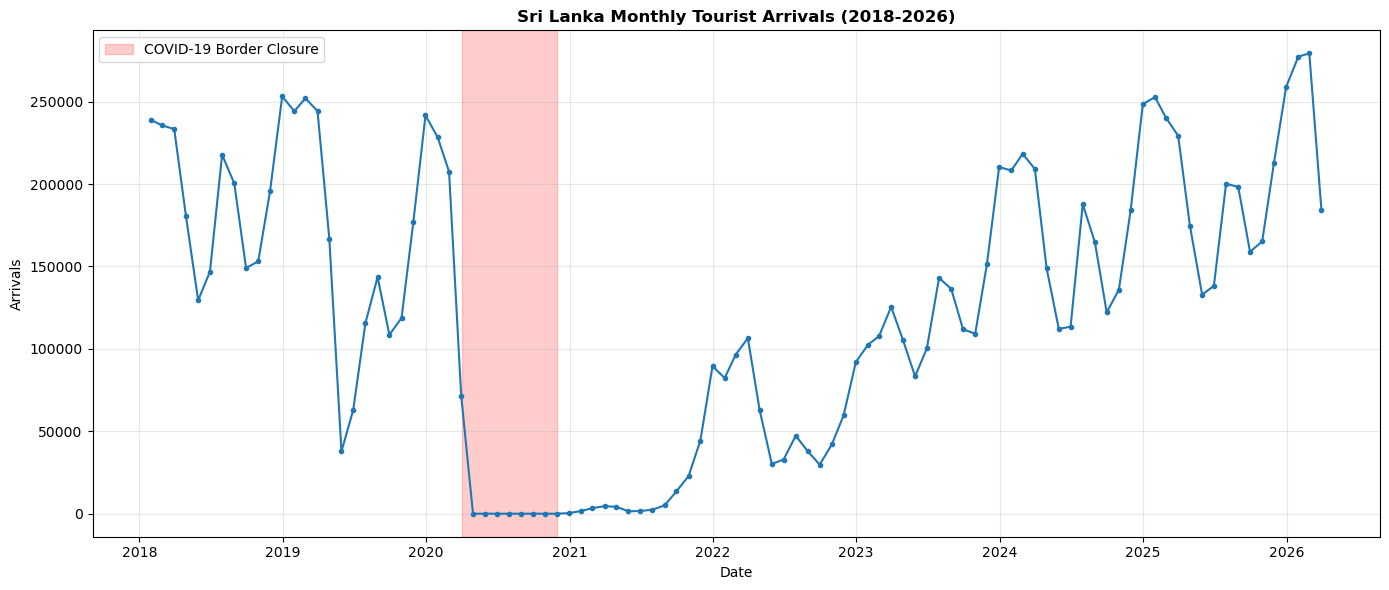

In [4]:
plt.figure()
plt.plot(y.index, y.values, marker='o', markersize=3)
plt.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-11-30'), alpha=0.2, color='red', label='COVID-19 Border Closure')
plt.title('Sri Lanka Monthly Tourist Arrivals (2018-2026)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Arrivals'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/01_historical.png', dpi=150)
plt.show()

## Step 4: Seasonal pattern check

Average arrivals by month — confirms tourism peaks in Dec–Mar (high season).

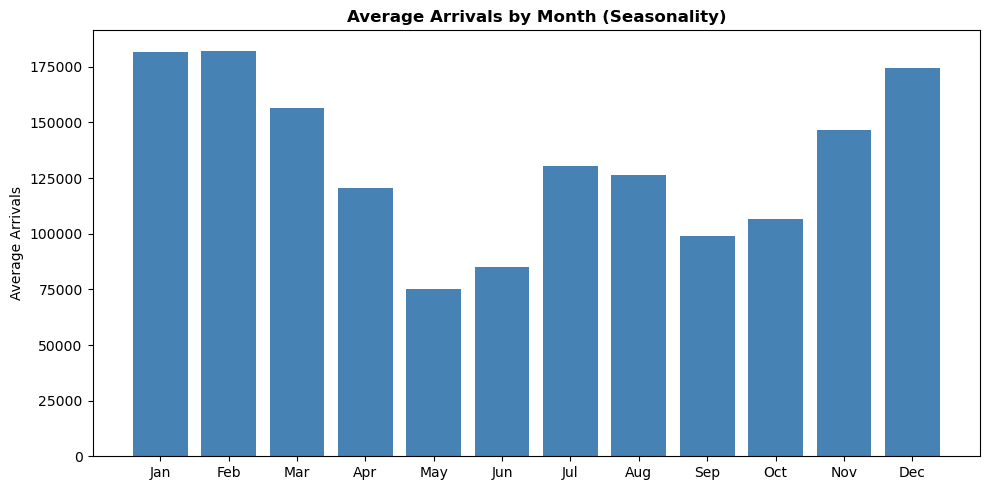

In [5]:
monthly_avg = y[y > 0].groupby(y[y > 0].index.month).mean()
plt.figure(figsize=(10,5))
plt.bar(range(1,13), monthly_avg.values, color='steelblue')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Arrivals by Month (Seasonality)', fontweight='bold')
plt.ylabel('Average Arrivals'); plt.tight_layout()
plt.savefig('../results/01_seasonality.png', dpi=150)
plt.show()

## Step 5: Save the cleaned series for the next notebooks

In [6]:
y.to_frame('Arrivals').to_csv('../data/monthly_total_arrivals.csv')
print('Saved cleaned data to ../data/monthly_total_arrivals.csv')
print('\nNotebook 01 complete. Move to 02_baseline_models.ipynb')

Saved cleaned data to ../data/monthly_total_arrivals.csv

Notebook 01 complete. Move to 02_baseline_models.ipynb
